Размер исходного изображения: 1000 × 563, каналов: 3
Центр изображения           : (500.0, 281.5)


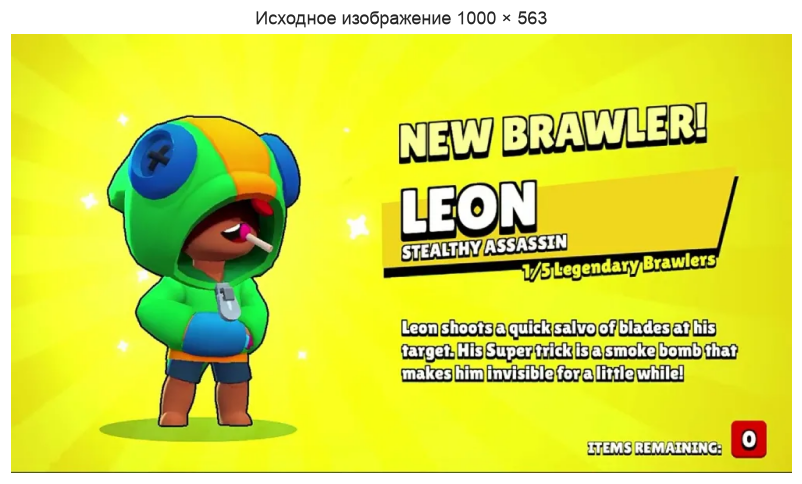

<Axes: title={'center': 'Исходное изображение 1000 × 563'}>

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

IMAGE_PATH = Path('../lab2/image.png')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {IMAGE_PATH.resolve()}')

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

height, width = image.shape[:2]
center = (width / 2, height / 2)


def show(img, title, ax=None, figsize=(8, 4.5)):
    # выводит BGR-изображение в правильных цветах
    created = ax is None
    if created:
        plt.figure(figsize=figsize)
        ax = plt.gca()
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
    if created:
        plt.tight_layout()
        plt.show()
    return ax


print(f'Размер исходного изображения: {width} × {height}, каналов: {image.shape[2]}')
print(f'Центр изображения           : {center}')
show(image, f'Исходное изображение {width} × {height}')

Было : 1000 × 563, соотношение сторон 1.776
Стало: 300 × 300, соотношение сторон 1.000
Коэффициенты масштаба: s_x = 0.300, s_y = 0.533
Число пикселей уменьшилось в 6.3 раза


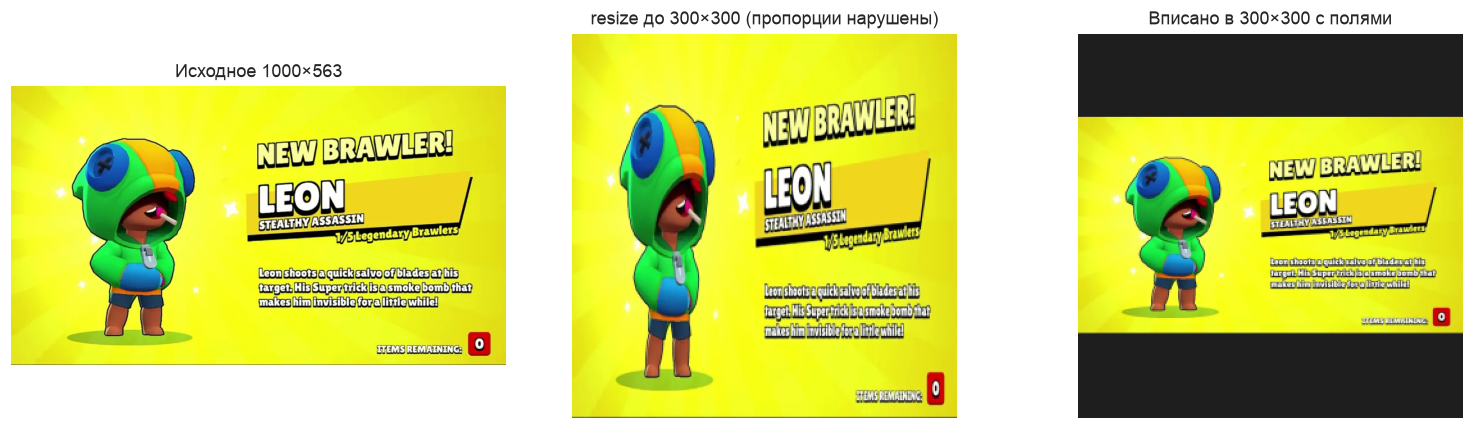

True

In [2]:
TARGET = (300, 300)   # (ширина, высота)

resized = cv2.resize(image, TARGET, interpolation=cv2.INTER_AREA)

print(f'Было : {width} × {height}, соотношение сторон {width / height:.3f}')
print(f'Стало: {resized.shape[1]} × {resized.shape[0]}, соотношение сторон '
      f'{resized.shape[1] / resized.shape[0]:.3f}')
print(f'Коэффициенты масштаба: s_x = {TARGET[0] / width:.3f}, s_y = {TARGET[1] / height:.3f}')
print(f'Число пикселей уменьшилось в {height * width / (TARGET[0] * TARGET[1]):.1f} раза')

# Вариант с сохранением пропорций: вписываем в квадрат и дополняем полями
scale = min(TARGET[0] / width, TARGET[1] / height)
new_w, new_h = int(round(width * scale)), int(round(height * scale))
fitted = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
pad_top = (TARGET[1] - new_h) // 2
pad_bottom = TARGET[1] - new_h - pad_top
letterboxed = cv2.copyMakeBorder(fitted, pad_top, pad_bottom, 0, 0,
                                 cv2.BORDER_CONSTANT, value=(30, 30, 30))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
show(image, f'Исходное {width}×{height}', axes[0])
show(resized, 'resize до 300×300 (пропорции нарушены)', axes[1])
show(letterboxed, 'Вписано в 300×300 с полями', axes[2])
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '01_resized_300x300.png'), resized)

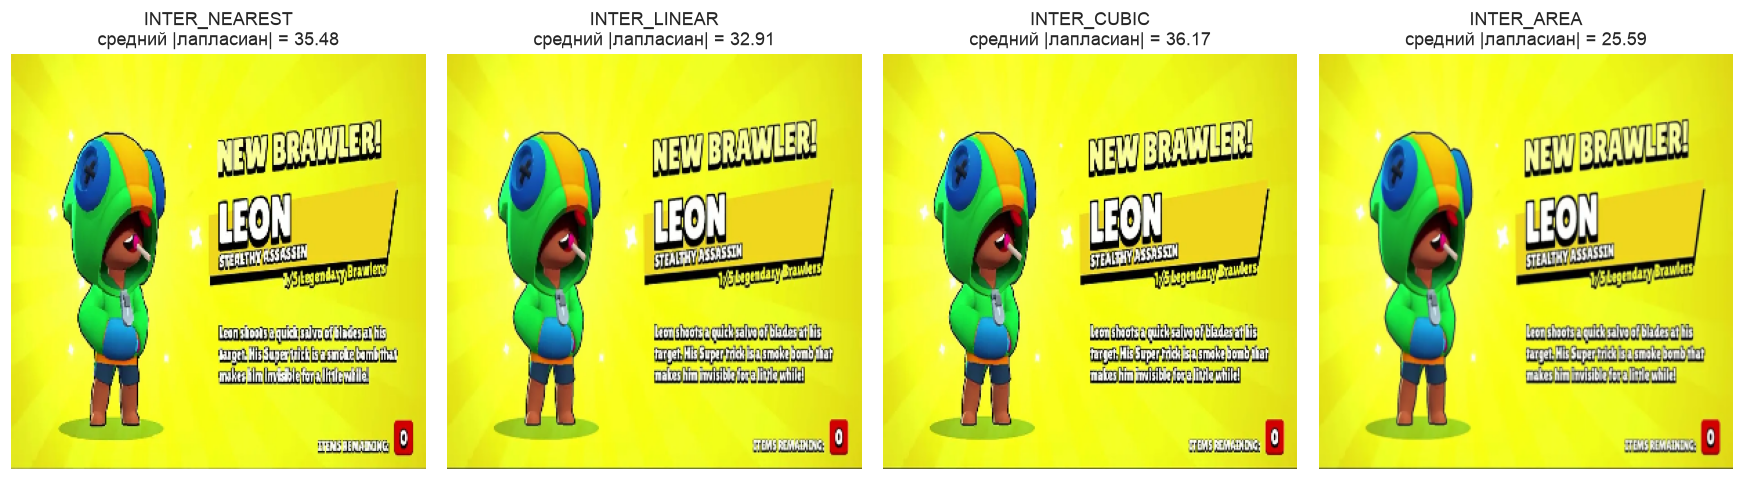

При уменьшении INTER_AREA даёт наиболее гладкий результат — он усредняет
все исходные пиксели, попавшие в новый, тогда как INTER_NEAREST просто
выбрасывает лишние строки и столбцы, из-за чего появляются «лесенки».


In [3]:
methods = {
    'INTER_NEAREST': cv2.INTER_NEAREST,
    'INTER_LINEAR': cv2.INTER_LINEAR,
    'INTER_CUBIC': cv2.INTER_CUBIC,
    'INTER_AREA': cv2.INTER_AREA,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (name, flag) in zip(axes, methods.items()):
    variant = cv2.resize(image, TARGET, interpolation=flag)
    # Насколько «зашумлён» результат: средний модуль лапласиана
    sharpness = np.abs(cv2.Laplacian(cv2.cvtColor(variant, cv2.COLOR_BGR2GRAY), cv2.CV_64F)).mean()
    show(variant, f'{name}\nсредний |лапласиан| = {sharpness:.2f}', ax)
plt.tight_layout()
plt.show()

print('При уменьшении INTER_AREA даёт наиболее гладкий результат — он усредняет')
print('все исходные пиксели, попавшие в новый, тогда как INTER_NEAREST просто')
print('выбрасывает лишние строки и столбцы, из-за чего появляются «лесенки».')

Матрица поворота M (2×3):
[[  0.9063   0.4226 -72.1209]
 [ -0.4226   0.9063 237.6835]]

α = s·cos θ = 0.9063   (элемент M[0,0])
β = s·sin θ = 0.4226   (элемент M[0,1])
Определитель линейной части: 1.000000 — поворот сохраняет площадь

Кадр без расширения: 1000 × 563 — углы изображения обрезаются
Кадр с расширением : 1144 × 932 — изображение помещается целиком


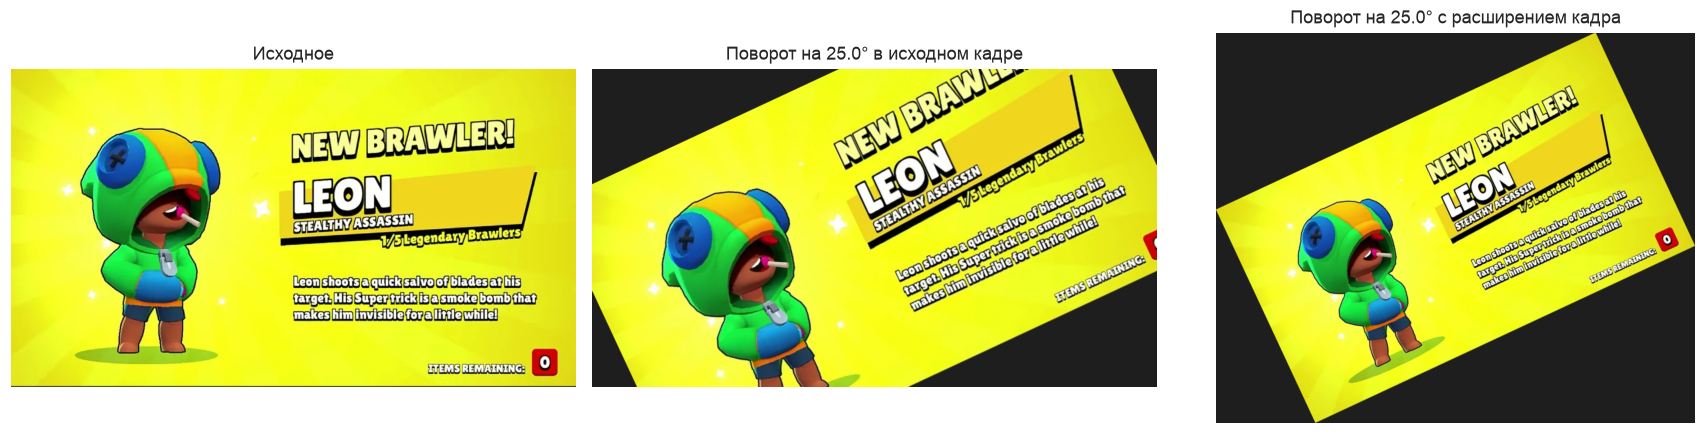

True

In [4]:
ANGLE = 25.0

M_rotate = cv2.getRotationMatrix2D(center, ANGLE, 1.0)
rotated = cv2.warpAffine(image, M_rotate, (width, height),
                         flags=cv2.INTER_LINEAR, borderValue=(30, 30, 30))

print('Матрица поворота M (2×3):')
print(np.round(M_rotate, 4))
print()
print(f'α = s·cos θ = {np.cos(np.deg2rad(ANGLE)):.4f}   (элемент M[0,0])')
print(f'β = s·sin θ = {np.sin(np.deg2rad(ANGLE)):.4f}   (элемент M[0,1])')
print(f'Определитель линейной части: {np.linalg.det(M_rotate[:, :2]):.6f} — поворот сохраняет площадь')

# Поворот с расширением кадра, чтобы углы не обрезались
cos_a, sin_a = abs(M_rotate[0, 0]), abs(M_rotate[0, 1])
new_w = int(height * sin_a + width * cos_a)
new_h = int(height * cos_a + width * sin_a)
M_expand = M_rotate.copy()
M_expand[0, 2] += new_w / 2 - center[0]
M_expand[1, 2] += new_h / 2 - center[1]
rotated_full = cv2.warpAffine(image, M_expand, (new_w, new_h), borderValue=(30, 30, 30))

print(f'\nКадр без расширения: {width} × {height} — углы изображения обрезаются')
print(f'Кадр с расширением : {new_w} × {new_h} — изображение помещается целиком')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
show(image, 'Исходное', axes[0])
show(rotated, f'Поворот на {ANGLE}° в исходном кадре', axes[1])
show(rotated_full, f'Поворот на {ANGLE}° с расширением кадра', axes[2])
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '02_rotated_25.png'), rotated)

Матрица переноса T (2×3):
[[   1.    0. -120.]
 [   0.    1.   60.]]

t_x = -120 → сдвиг влево на 120 пикс.
t_y = 60 → сдвиг вниз  на 60 пикс.

Контрольная точка [400. 200.] → [280. 260.]
Справа появилась полоса фона шириной 120 пикс.,
сверху — полоса высотой 60 пикс.: эти пиксели в исходном изображении отсутствуют.


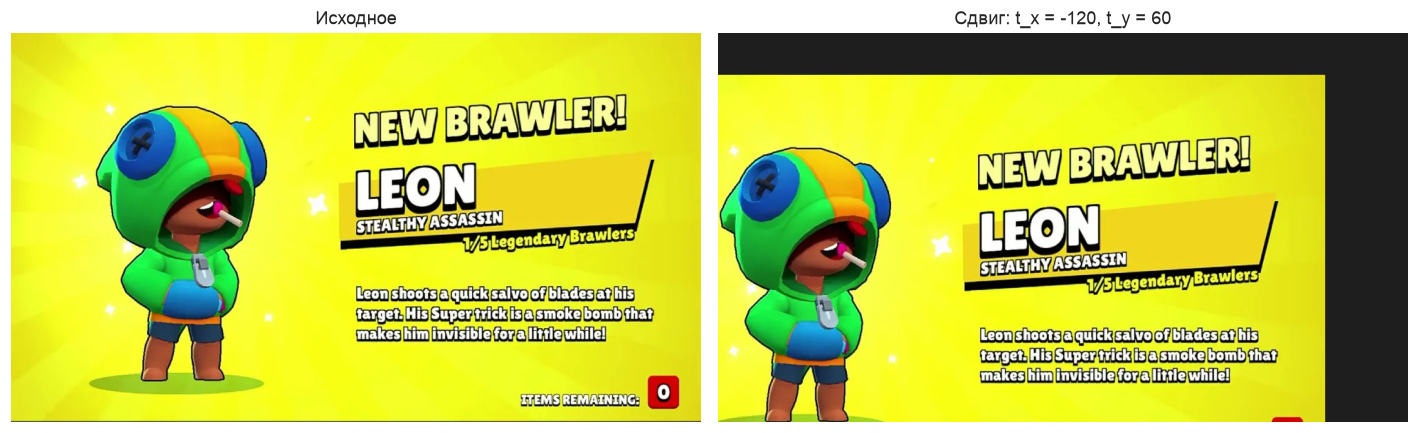

True

In [5]:
TX, TY = -120, 60

T = np.float32([[1, 0, TX],
                [0, 1, TY]])
shifted = cv2.warpAffine(image, T, (width, height), borderValue=(30, 30, 30))

print('Матрица переноса T (2×3):')
print(T)
print(f'\nt_x = {TX} → сдвиг влево на {abs(TX)} пикс.')
print(f't_y = {TY} → сдвиг вниз  на {TY} пикс.')

probe = np.array([[400.0, 200.0]])
probe_moved = cv2.transform(probe.reshape(1, -1, 2), T).reshape(-1, 2)
print(f'\nКонтрольная точка {probe[0]} → {probe_moved[0]}')

# Полоса пикселей, которая ушла за кадр, заполняется цветом borderValue
lost_right = abs(TX)
print(f'Справа появилась полоса фона шириной {lost_right} пикс.,')
print(f'сверху — полоса высотой {TY} пикс.: эти пиксели в исходном изображении отсутствуют.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
show(image, 'Исходное', axes[0])
show(shifted, f'Сдвиг: t_x = {TX}, t_y = {TY}', axes[1])
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '03_shifted.png'), shifted)

flip(0)  ≡ image[::-1, :]  — совпадает: True
flip(1)  ≡ image[:, ::-1]  — совпадает: True
flip(-1) ≡ image[::-1, ::-1] — совпадает: True

flip(0) ≡ warpAffine с матрицей diag(1, −1) и переносом на H−1: True
Определитель линейной части при отражении: -1.0 — отрицательный, ориентация меняется на зеркальную


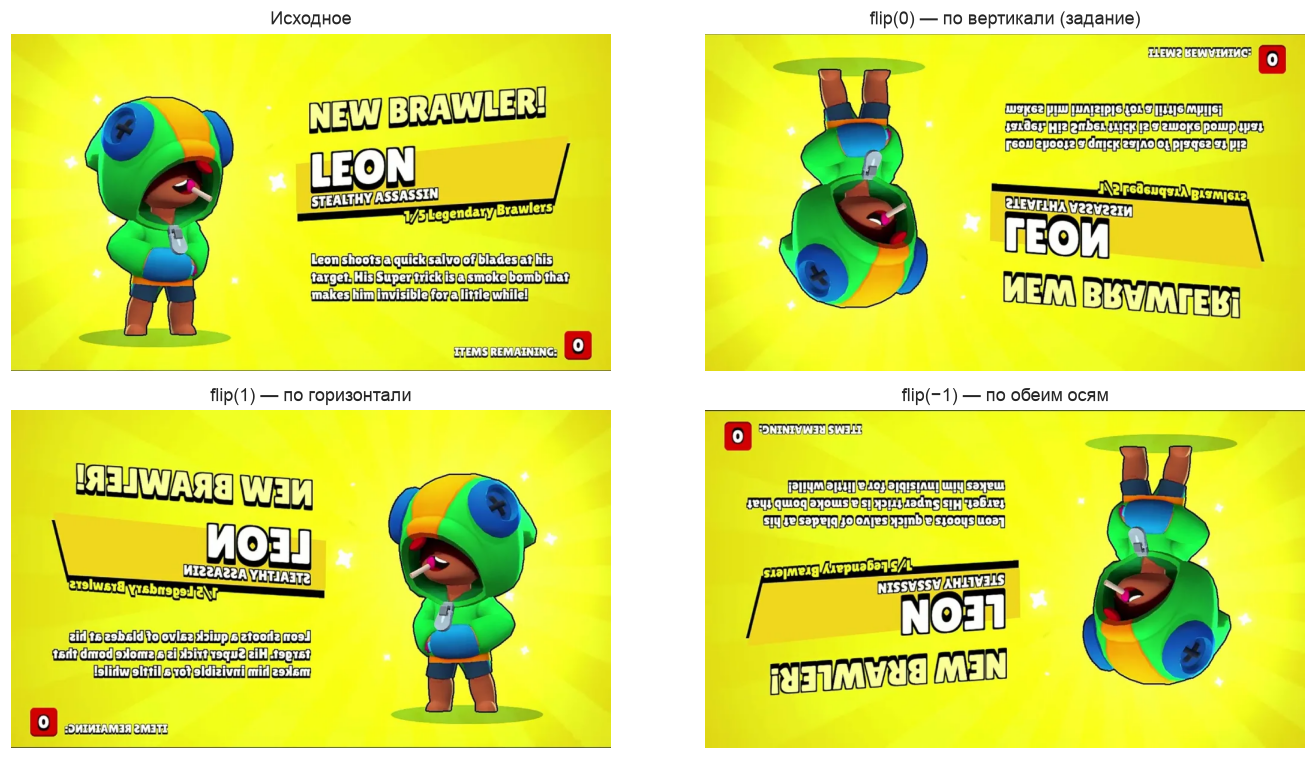

True

In [6]:
flipped_v = cv2.flip(image, 0)    # по вертикали: верх ↔ низ
flipped_h = cv2.flip(image, 1)    # по горизонтали: лево ↔ право
flipped_both = cv2.flip(image, -1)

# То же самое через матрицу аффинного преобразования
M_flip_v = np.float32([[1, 0, 0],
                       [0, -1, height - 1]])
flipped_v_matrix = cv2.warpAffine(image, M_flip_v, (width, height))

print(f'flip(0)  ≡ image[::-1, :]  — совпадает: {np.array_equal(flipped_v, image[::-1, :])}')
print(f'flip(1)  ≡ image[:, ::-1]  — совпадает: {np.array_equal(flipped_h, image[:, ::-1])}')
print(f'flip(-1) ≡ image[::-1, ::-1] — совпадает: {np.array_equal(flipped_both, image[::-1, ::-1])}')
print(f'\nflip(0) ≡ warpAffine с матрицей diag(1, −1) и переносом на H−1: '
      f'{np.array_equal(flipped_v, flipped_v_matrix)}')
print(f'Определитель линейной части при отражении: {np.linalg.det(M_flip_v[:, :2]):.1f} '
      '— отрицательный, ориентация меняется на зеркальную')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
show(image, 'Исходное', axes[0, 0])
show(flipped_v, 'flip(0) — по вертикали (задание)', axes[0, 1])
show(flipped_h, 'flip(1) — по горизонтали', axes[1, 0])
show(flipped_both, 'flip(−1) — по обеим осям', axes[1, 1])
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '04_flipped_vertical.png'), flipped_v)

Матрица аффинного преобразования M (2×3):
[[   1.1502    0.7434 -166.8679]
 [  -0.1977    0.9208  117.5849]]

Определитель линейной части: 1.2060
— во столько раз меняется площадь любой фигуры на изображении.

Проверка соответствия точек:
  P1: [150. 100.] → задано [ 80. 180.], получено [ 80. 180.]
  P2: [850. 120.] → задано [900.  60.], получено [900.  60.]
  P3: [200. 480.] → задано [420. 520.], получено [420. 520.]


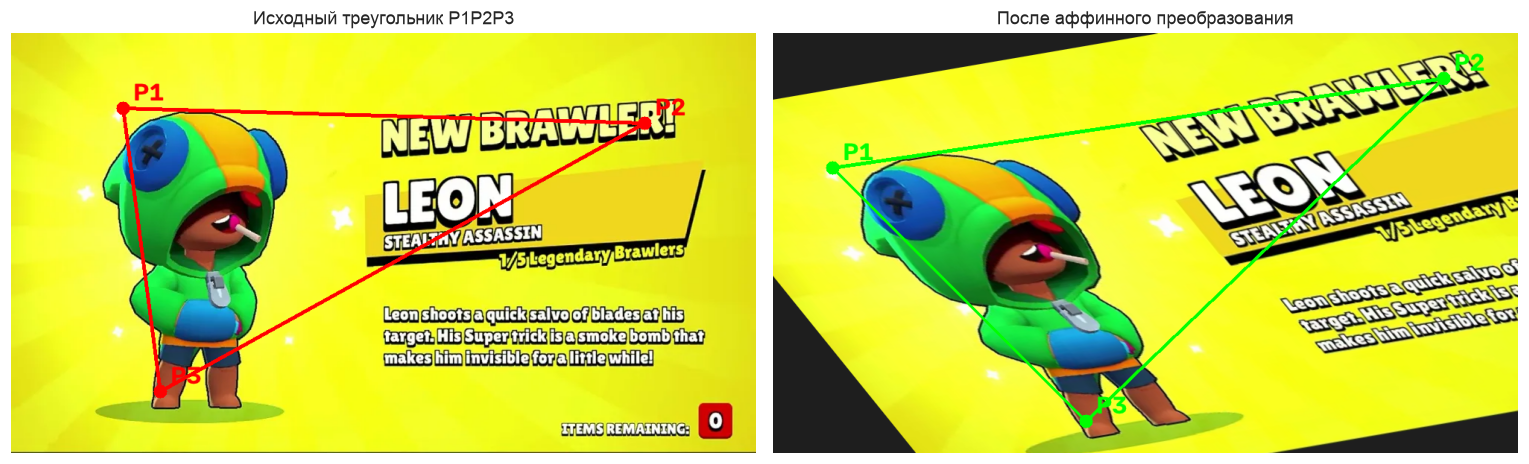

True

In [7]:
pts_src = np.float32([[150, 100],
                      [850, 120],
                      [200, 480]])
pts_dst = np.float32([[80, 180],
                      [900, 60],
                      [420, 520]])

M_affine = cv2.getAffineTransform(pts_src, pts_dst)
affine = cv2.warpAffine(image, M_affine, (width, height), borderValue=(30, 30, 30))

print('Матрица аффинного преобразования M (2×3):')
print(np.round(M_affine, 4))
print(f'\nОпределитель линейной части: {np.linalg.det(M_affine[:, :2]):.4f}')
print('— во столько раз меняется площадь любой фигуры на изображении.')

# Проверка: точки действительно переходят одна в другую
mapped = cv2.transform(pts_src.reshape(1, -1, 2), M_affine).reshape(-1, 2)
print('\nПроверка соответствия точек:')
for i, (src, want, got) in enumerate(zip(pts_src, pts_dst, mapped), 1):
    print(f'  P{i}: {src} → задано {want}, получено {np.round(got, 3)}')

src_marked = image.copy()
dst_marked = affine.copy()
for img_marked, pts, color in ((src_marked, pts_src, (0, 0, 255)), (dst_marked, pts_dst, (0, 255, 0))):
    cv2.polylines(img_marked, [pts.astype(np.int32)], isClosed=True, color=color, thickness=4)
    for idx, (x, y) in enumerate(pts.astype(int), 1):
        cv2.circle(img_marked, (x, y), 9, color, -1)
        cv2.putText(img_marked, f'P{idx}', (x + 14, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
show(src_marked, 'Исходный треугольник P1P2P3', axes[0])
show(dst_marked, 'После аффинного преобразования', axes[1])
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '05_affine_triangle.png'), affine)

In [8]:
def cross2(u, v):
    # векторное произведение двух плоских векторов даёт скаляр
    return float(u[0] * v[1] - u[1] * v[0])


def triangle_metrics(points):
    a, b, c = points
    sides = np.array([np.linalg.norm(b - a), np.linalg.norm(c - b), np.linalg.norm(a - c)])
    # угол при вершине вычисляем через скалярное произведение
    angles = []
    for p, q, r in ((a, b, c), (b, c, a), (c, a, b)):
        v1, v2 = q - p, r - p
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        angles.append(np.degrees(np.arccos(np.clip(cos_angle, -1, 1))))
    area = 0.5 * abs(cross2(b - a, c - a))
    return sides, np.array(angles), area


sides_src, angles_src, area_src = triangle_metrics(pts_src)
sides_dst, angles_dst, area_dst = triangle_metrics(pts_dst)

print(f'{"":<12}{"до":>26}{"после":>26}')
print(f'{"стороны":<12}{str(np.round(sides_src, 1)):>26}{str(np.round(sides_dst, 1)):>26}')
print(f'{"углы, °":<12}{str(np.round(angles_src, 1)):>26}{str(np.round(angles_dst, 1)):>26}')
print(f'{"сумма углов":<12}{angles_src.sum():>26.1f}{angles_dst.sum():>26.1f}')
print(f'{"площадь":<12}{area_src:>26.1f}{area_dst:>26.1f}')
print(f'\nОтношение площадей: {area_dst / area_src:.4f}')
print(f'Определитель матрицы: {np.linalg.det(M_affine[:, :2]):.4f} — совпадает с отношением площадей.')
print('\nУглы изменились, стороны изменились, но сумма углов осталась 180°:')
print('фигура по-прежнему треугольник, прямые остались прямыми.')

                                    до                     после
стороны            [700.3 743.  383.3]       [828.7 664.8 480.8]
углы, °               [80.9 30.6 68.5]          [53.3 35.5 91.2]
сумма углов                      180.0                     180.0
площадь                       132500.0                  159800.0

Отношение площадей: 1.2060
Определитель матрицы: 1.2060 — совпадает с отношением площадей.

Углы изменились, стороны изменились, но сумма углов осталась 180°:
фигура по-прежнему треугольник, прямые остались прямыми.


до : sin∠(AB, DC) = 0.000e+00, sin∠(AD, BC) = 0.000e+00 → стороны параллельны
после: sin∠(AB, DC) = 1.792e-08, sin∠(AD, BC) = 1.159e-07 → стороны параллельны

Середина диагонали, преобразованная:   [555.151  281.8114]
Середина преобразованной диагонали:    [555.151  281.8114]
Совпали — аффинное преобразование сохраняет отношение длин на прямой.


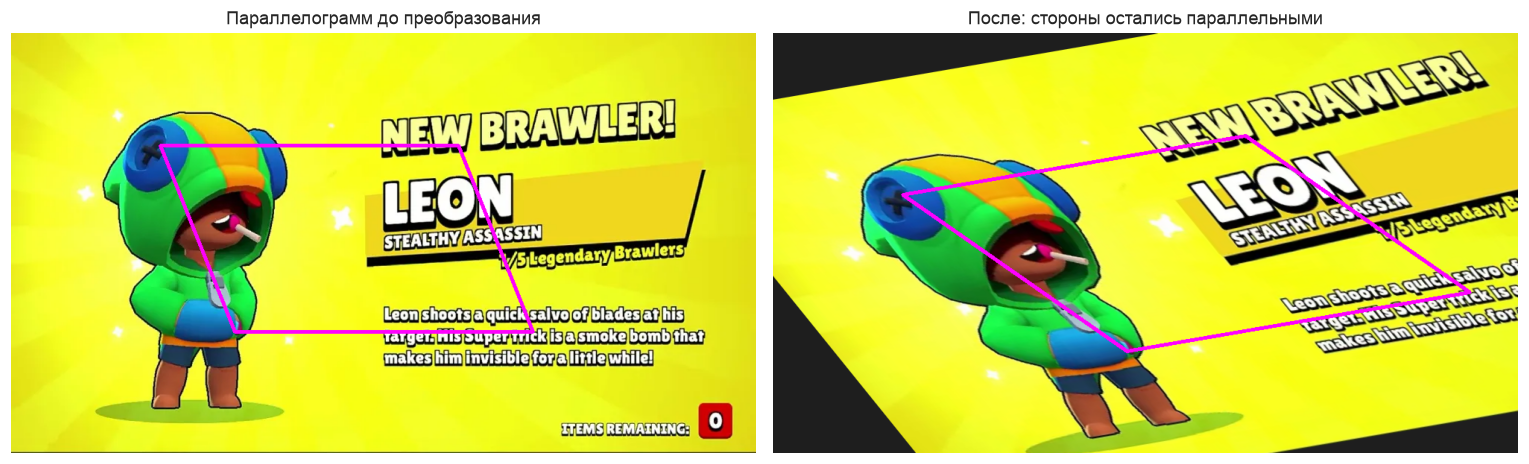

In [9]:
parallelogram = np.float32([[200, 150], [600, 150], [700, 400], [300, 400]])
warped_pts = cv2.transform(parallelogram.reshape(1, -1, 2), M_affine).reshape(-1, 2)


def side_vectors(pts):
    return pts[1] - pts[0], pts[2] - pts[3], pts[3] - pts[0], pts[2] - pts[1]


for label, pts in (('до ', parallelogram), ('после', warped_pts)):
    ab, dc, ad, bc = side_vectors(pts)
    # sin угла между сторонами: нормируем на длины, иначе величина зависит от масштаба
    sin1 = abs(cross2(ab, dc)) / (np.linalg.norm(ab) * np.linalg.norm(dc))
    sin2 = abs(cross2(ad, bc)) / (np.linalg.norm(ad) * np.linalg.norm(bc))
    print(f'{label}: sin∠(AB, DC) = {sin1:.3e}, sin∠(AD, BC) = {sin2:.3e} '
          f'→ стороны {"параллельны" if max(sin1, sin2) < 1e-5 else "НЕ параллельны"}')

mid_src = (parallelogram[0] + parallelogram[2]) / 2
mid_after_transform = cv2.transform(mid_src.reshape(1, 1, 2), M_affine).reshape(2)
mid_of_transformed = (warped_pts[0] + warped_pts[2]) / 2
print(f'\nСередина диагонали, преобразованная:   {np.round(mid_after_transform, 4)}')
print(f'Середина преобразованной диагонали:    {np.round(mid_of_transformed, 4)}')
print('Совпали — аффинное преобразование сохраняет отношение длин на прямой.')

canvas_src = image.copy()
canvas_dst = affine.copy()
cv2.polylines(canvas_src, [parallelogram.astype(np.int32)], True, (255, 0, 255), 4)
cv2.polylines(canvas_dst, [warped_pts.astype(np.int32)], True, (255, 0, 255), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
show(canvas_src, 'Параллелограмм до преобразования', axes[0])
show(canvas_dst, 'После: стороны остались параллельными', axes[1])
plt.tight_layout()
plt.show()

Итоговая матрица (отражение → поворот → сдвиг):
[[ 9.063000e-01 -4.226000e-01  4.539050e+01]
 [-4.226000e-01 -9.063000e-01  8.070285e+02]]

Средняя разница между «одной матрицей» и «тремя проходами»: 7.535
Максимальная разница: 225 — расхождение возникает из-за
повторной интерполяции и заливки границ на промежуточных шагах.


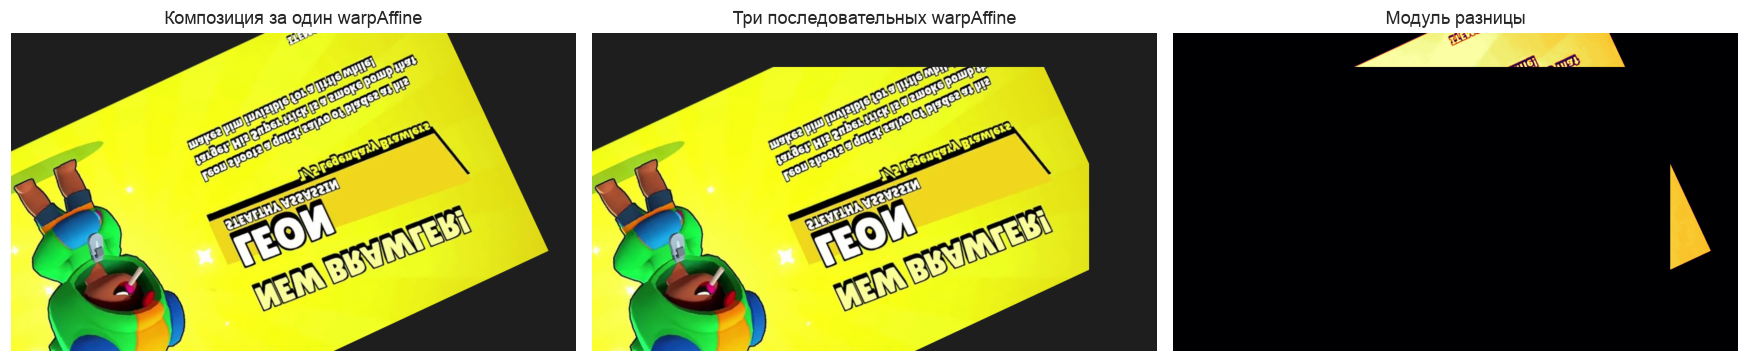

In [10]:
def to_3x3(m):
    return np.vstack([m, [0, 0, 1]])


M_total = to_3x3(T) @ to_3x3(M_rotate) @ to_3x3(M_flip_v)
combined_once = cv2.warpAffine(image, M_total[:2], (width, height), borderValue=(30, 30, 30))

step_by_step = cv2.flip(image, 0)
step_by_step = cv2.warpAffine(step_by_step, M_rotate, (width, height), borderValue=(30, 30, 30))
step_by_step = cv2.warpAffine(step_by_step, T, (width, height), borderValue=(30, 30, 30))

difference = cv2.absdiff(combined_once, step_by_step)
print('Итоговая матрица (отражение → поворот → сдвиг):')
print(np.round(M_total[:2], 4))
print(f'\nСредняя разница между «одной матрицей» и «тремя проходами»: {difference.mean():.3f}')
print(f'Максимальная разница: {difference.max()} — расхождение возникает из-за')
print('повторной интерполяции и заливки границ на промежуточных шагах.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
show(combined_once, 'Композиция за один warpAffine', axes[0])
show(step_by_step, 'Три последовательных warpAffine', axes[1])
axes[2].imshow(difference.max(axis=2), cmap='inferno')
axes[2].set_title('Модуль разницы')
axes[2].axis('off')
plt.tight_layout()
plt.show()

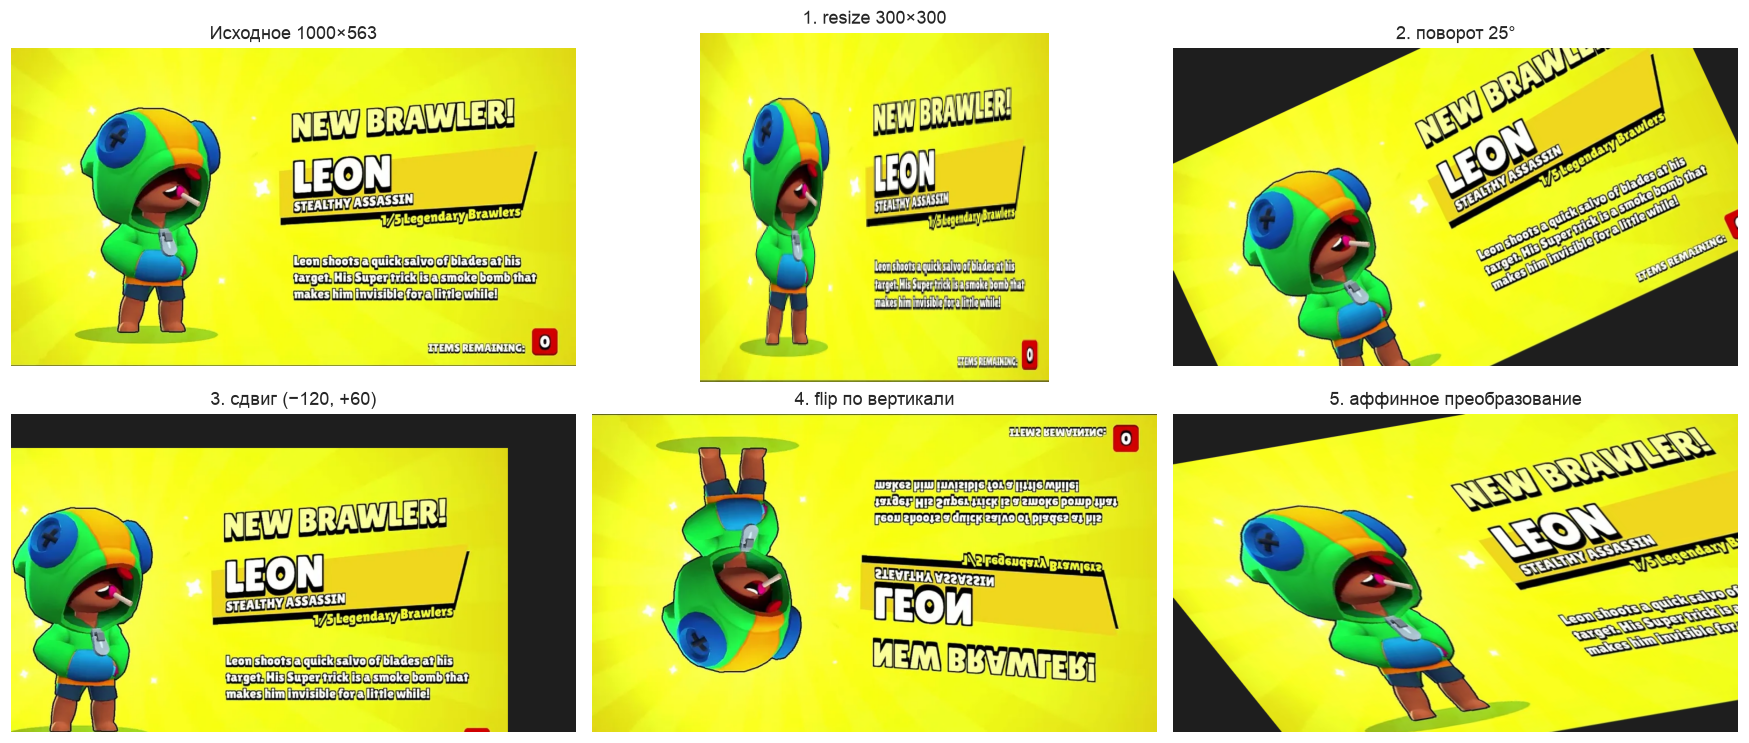

01_resized_300x300.png          125.2 КБ
02_rotated_25.png               537.0 КБ
03_shifted.png                  445.6 КБ
04_flipped_vertical.png         520.1 КБ
05_affine_triangle.png          514.8 КБ


In [11]:
gallery = [
    (image, f'Исходное {width}×{height}'),
    (resized, '1. resize 300×300'),
    (rotated, '2. поворот 25°'),
    (shifted, '3. сдвиг (−120, +60)'),
    (flipped_v, '4. flip по вертикали'),
    (affine, '5. аффинное преобразование'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (img, title) in zip(axes.ravel(), gallery):
    show(img, title, ax)
plt.tight_layout()
plt.show()

for path in sorted(OUTPUT_DIR.iterdir()):
    print(f'{path.name:<28} {path.stat().st_size / 1024:8.1f} КБ')